### Problem Statement
ABC Co's 2014-2018 sales data to identify key revenue and profit drivers across products, channels, and regions, uncover seasonal trends and outliers, and align performance against budgets. Use these insights to optimize pricing, promotions and market expansion for sustainable growth and reduced concentration risk.

### Objective
Deliver actionable insights from Acme Co.’s 2014–2018 sales data to:

1)Identify top-performing products, channels, and regions driving revenue and profit\
2)Uncover seasonal trends and anomalies for optimized planning\
3)Spot pricing and margin risks from outlier transactions\
4)Inform pricing, promotion, and market-expansion strategies

These findings will guide the design of a Power BI dashboard to support strategic decision-making and sustainable growth.

### Setup & Configuration

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Ingestion

In [2]:
sheets = pd.read_excel(r'C:\Users\Maneesh\Desktop\Projects\sales_analysis\Regional_Sales_Dataset.xlsx', sheet_name=None)

In [3]:
#Assign dataframe to each sheet
df_sales=sheets['Sales Orders']
df_customers=sheets['Customers']
df_products=sheets['Products']
df_regions=sheets['Regions']
df_state_reg=sheets['State Regions']
df_budgets=sheets['2017 Budgets']

### Data Profiling / Initial Inspection

In [4]:
print (f"df_sales shape: ",df_sales.shape)
print (f"df_customers shape: ",df_customers.shape)
print (f"df_products shape: ",df_products.shape)
print (f"df_regions shape: ",df_regions.shape)
print (f"df_state_reg shape: ",df_state_reg.shape)
print (f"df_budgets shape: ",df_budgets.shape)

df_sales shape:  (64104, 12)
df_customers shape:  (175, 2)
df_products shape:  (30, 2)
df_regions shape:  (994, 15)
df_state_reg shape:  (49, 3)
df_budgets shape:  (30, 2)


In [5]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [6]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [7]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [8]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [9]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [10]:
df_state_reg.columns = df_state_reg.iloc[0]
df_state_reg = df_state_reg.drop(0).reset_index(drop=True)
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [11]:
df_budgets.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [12]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [13]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [14]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [15]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [16]:
df_state_reg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [17]:
df_state_reg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

### Data Cleaning and Wrangling

In [18]:
#merge with customers
df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

In [19]:
#merge with products
df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [20]:
#merge with Regions
df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)

In [21]:
#merge with State Regions
df = df.merge(
    df_state_reg[["State Code", "Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
)

In [22]:
#merge with Budgets
df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
)

In [23]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [24]:
#Customer Index
#Index
#id
#State Code

#Clean up redundant columns
cols_to_drop = ['Customer Index', 'Index', 'id', 'State Code']
df=df.drop(columns = cols_to_drop, errors='ignore')
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [25]:
#convert all columns to lower case for consistency and ease of access
df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [26]:
df.to_csv('dfdata.csv')

In [27]:
#keep the inportant columns and removing the ones not needed
cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'
]

In [28]:
df = df[cols_to_keep]
df.head()

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [29]:
#Rename the columns
df = df.rename(columns={
    'ordernumber':'order_number',
    'orderdate':'order_date',
    'customer names':'customer_name',
    'product name':'product_name',
    'order quantity':'order_quantity',
    'unit price':'unit_price',
    'line total':'revenue',
    'total unit cost':'cost',
    'state_code':'state',
    'state':'state_name',
    'latitude':'lat',
    'longitude':'lon',
    '2017 budgets':'budget'
})
df.head(1)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231


In [30]:
#blank out budgets for non-2017 order
df.loc[df['order_date'].dt.year != 2017, 'budget']=pd.NA

#line total is revenue
df[['order_date', 'product_name', 'revenue', 'budget']].head()

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   customer_name   64104 non-null  object        
 3   channel         64104 non-null  object        
 4   product_name    64104 non-null  object        
 5   order_quantity  64104 non-null  int64         
 6   unit_price      64104 non-null  float64       
 7   revenue         64104 non-null  float64       
 8   cost            64104 non-null  float64       
 9   state           64104 non-null  object        
 10  county          64104 non-null  object        
 11  state_name      64104 non-null  object        
 12  region          64104 non-null  object        
 13  lat             64104 non-null  float64       
 14  lon             64104 non-null  float64       
 15  bu

In [32]:
#filter data for the year 2017
df_2017=df[df['order_date'].dt.year == 2017]

In [33]:
df_2017.isnull().sum()

order_number      0
order_date        0
customer_name     0
channel           0
product_name      0
order_quantity    0
unit_price        0
revenue           0
cost              0
state             0
county            0
state_name        0
region            0
lat               0
lon               0
budget            0
dtype: int64

In [34]:
df_2017.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,Hudson County,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Mesa County,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,Los Angeles County,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Dubuque County,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Hernando County,Florida,South,28.47689,-82.52546,3050087.565


### Feature Engineering

##### Revenue is calculated as order_quantity * unit_price
##### Total Cost is calculated as order_quantity * cost
##### Profit = Revenue - Total Cost

In [35]:
df['total_cost'] = df['order_quantity'] * df['cost']

In [36]:
df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = df['profit'] / df['revenue'] * 100

In [37]:
df.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


In [38]:
df

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,Bucks County,Pennsylvania,Northeast,40.15511,-74.82877,NaN,11765.736,10022.664,46.0
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,Cook County,Illinois,Midwest,42.11030,-88.03424,NaN,3474.486,1711.314,33.0
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,Broward County,Florida,South,26.24453,-80.20644,NaN,29133.610,14349.390,33.0
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,Erie County,New York,Northeast,42.91002,-78.74182,NaN,20511.246,7206.654,26.0


## **Exploratory Data Analysis**

### 1. Monthly Sales Trend Over Time
Goal: Track revenue trends over time to detect seasonality or sales spikes\
Chart: Line chart\
EDA Type: Temporal (time series)\
Structure: Line with markers to highlight monthly revenue points clearly

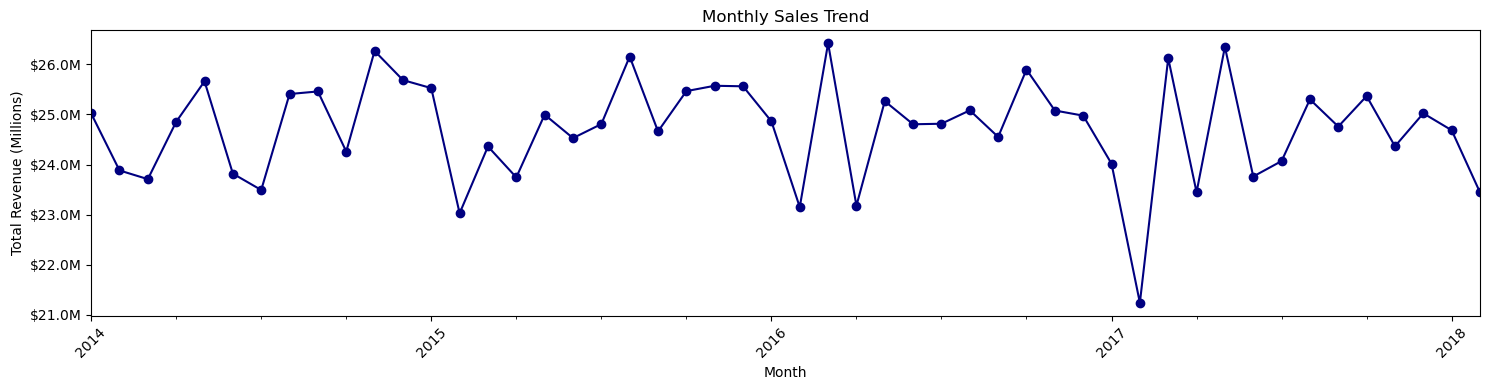

In [39]:
# Extracting month and year for trend analysis
df['order_month'] = df['order_date'].dt.to_period('M')

# Grouping by month and calculating total revenue
monthly_sales = df.groupby('order_month')['revenue'].sum()

# Plotting the sales trend
plt.figure(figsize=(15, 4))
monthly_sales.plot(marker='o', color='navy')

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Insights-
Sales consistently cycle between 23M and 26M, with clear peaks in late spring to early summer (May–June) and lows in start of the year (January-February).\
The overall trend remains stable year over year, reflecting a reliable seasonal demand pattern.\
However, the sharp revenue drop in early 2017 stands out as an outlier, warranting closer investigation into potential causes such as market disruptions or mistimed promotions.

### 2. Monthly Sales Trend (All Years Combined)
Goal: Highlight overall seasonality patterns by aggregating sales across all years for each calendar month\
Chart: Line chart\
EDA Type: Temporal (time series)\
Structure: Line with markers, months ordered January to December based on month number

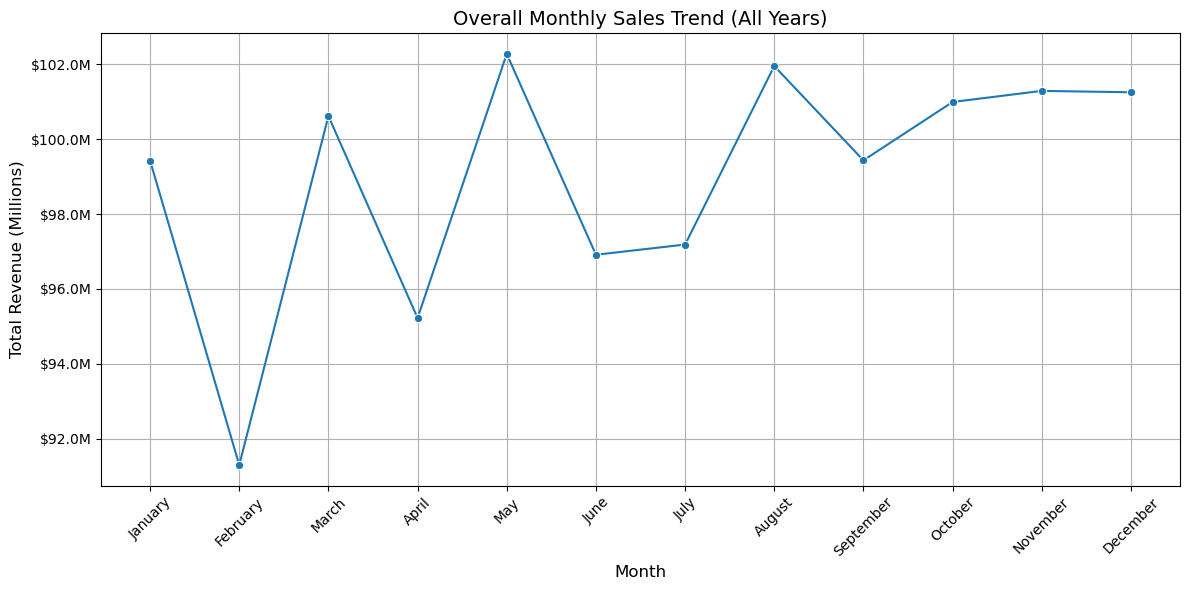

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Create a copy for plotting
df_plot = df.copy()

# Convert order_date to datetime
df_plot['order_date'] = pd.to_datetime(df_plot['order_date'])

# Remove 2018 data
df_plot = df_plot[df_plot['order_date'].dt.year != 2018]

# Extract month name
df_plot['month'] = df_plot['order_date'].dt.strftime('%B')

# Aggregate revenue
monthly_trend = df_plot.groupby('month')['revenue'].sum().reset_index()

# Sort months correctly
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_trend['month'] = pd.Categorical(
    monthly_trend['month'],
    categories=month_order,
    ordered=True
)

monthly_trend = monthly_trend.sort_values('month')

# Convert revenue to millions
monthly_trend['revenue_millions'] = monthly_trend['revenue'] / 1_000_000

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trend, x='month', y='revenue_millions', marker='o')

# Titles
plt.title('Overall Monthly Sales Trend (All Years)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (Millions)', fontsize=12)

# Rotate labels
plt.xticks(rotation=45)

# Format y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.1f}M')
)

# Grid
plt.grid(True)
plt.tight_layout()

plt.show()

#### Insights-
Across all years, January starts strong at around 99M, followed by a sharp decline in February to nearly 91M, marking the lowest point.\
Sales recover steadily from March onward, with noticeable peaks in May and August (≈ \102M).\
From September to December, sales stabilize in the 100M-101M range, maintaining consistent performance toward year-end.\
This pattern highlights a post–New Year dip, strong mid-year peaks, and stable year-end demand, indicating a predictable seasonal cycle across all years.

### 3. Top 10 Products by Revenue (in Millions)
Goal: Identify the highest-grossing products to focus marketing and inventory efforts\
Chart: Horizontal bar chart\
EDA Type: Univariate\
Structure: Bars sorted descending to show top 10 products with revenue scaled in millions

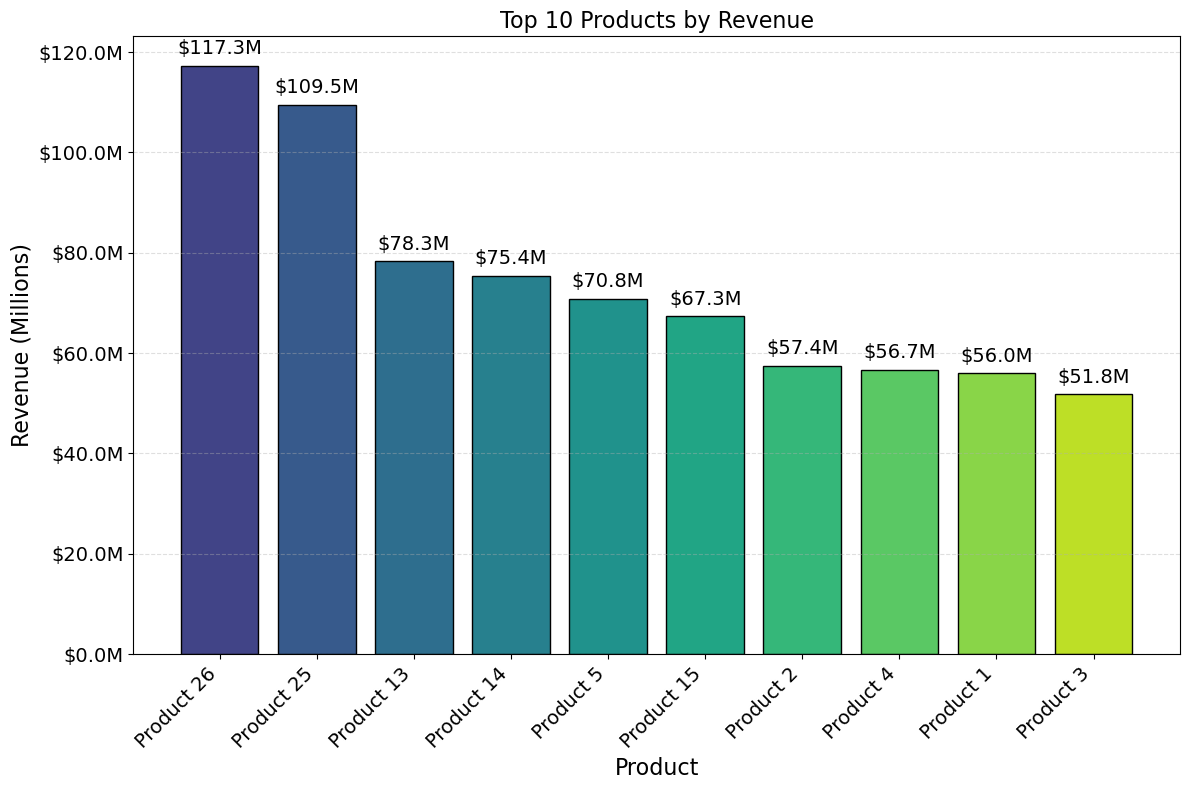

In [41]:
# Get top 10 products
top_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Convert to millions
top_products['revenue_millions'] = top_products['revenue'] / 1_000_000

# Gradient colors
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_products)))

# Plot
plt.figure(figsize=(12, 8))
bars = plt.bar(
    top_products['product_name'],
    top_products['revenue_millions'],
    color=colors,
    edgecolor='black'
)

# Titles
plt.title('Top 10 Products by Revenue', fontsize=16)
plt.xlabel('Product', fontsize=16)
plt.ylabel('Revenue (Millions)', fontsize=16)

# Rotate labels
plt.xticks(rotation=45, ha='right',fontsize=14)

plt.yticks(fontsize=14)
# Format y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.1f}M')
)

# Add labels with proper gap
for bar, v in zip(bars, top_products['revenue_millions']):
    gap = max(top_products['revenue_millions']) * 0.02  # dynamic gap (2%)
    plt.text(
        bar.get_x() + bar.get_width()/2,
        v + gap,
        f'${v:.1f}M',
        ha='center',
        
        fontsize=14,
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### Insights-
Products 26 and 25 dominate (~110M–117M), with a clear gap from the rest of the portfolio.\
Mid-tier products (70M–78M) show stable performance but lack strong growth momentum.\
Lower-tier products cluster around 51M–57M, indicating similar constraints and opportunities for optimization.

### 3a. Bottom 10 Products by Revenue (in Millions)
Goal: Identify the highest-grossing products to focus marketing and inventory efforts\
Chart: Horizontal bar chart\
EDA Type: Univariate\
Structure: Bars sorted descending to show top 10 products with revenue scaled in millions

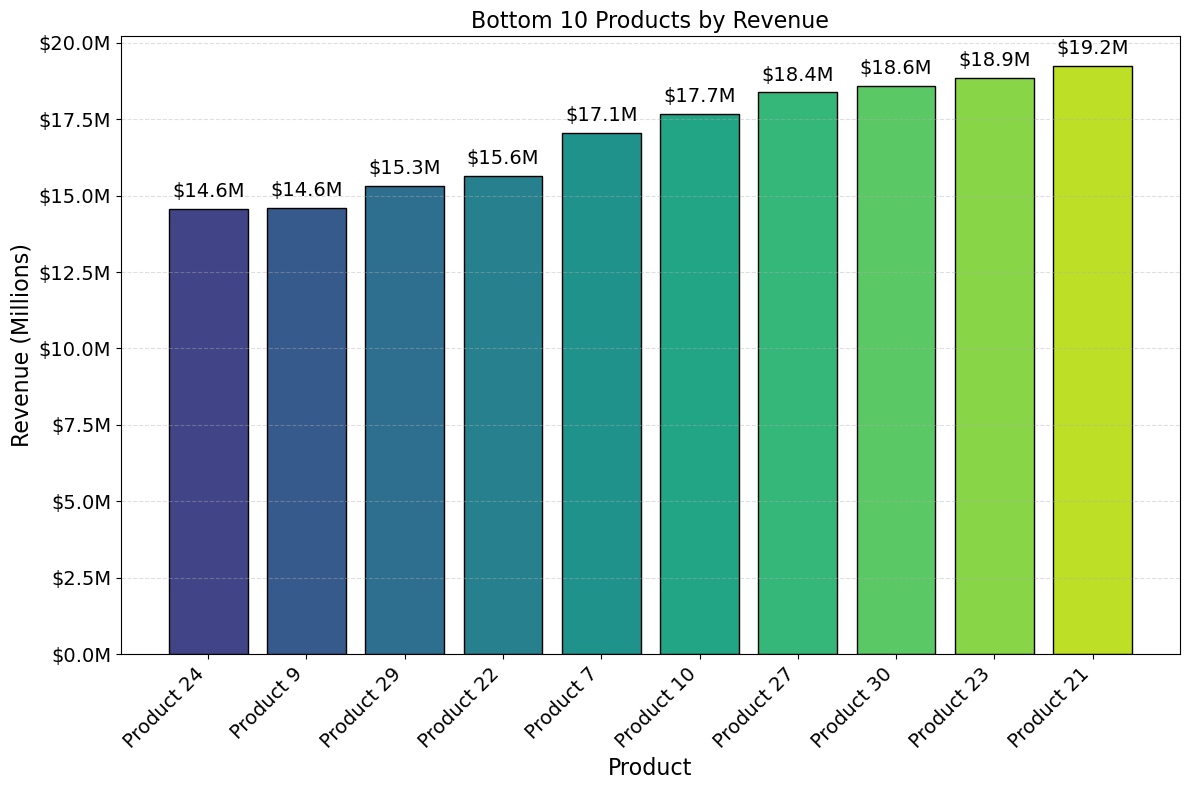

In [42]:
# Get bottom 10 products
bottom_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .sort_values(ascending=True)  # smallest first
    .head(10)
    .reset_index()
)

# Convert to millions
bottom_products['revenue_millions'] = bottom_products['revenue'] / 1_000_000

# Gradient colors
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(bottom_products)))

# Plot
plt.figure(figsize=(12, 8))
bars = plt.bar(
    bottom_products['product_name'],
    bottom_products['revenue_millions'],
    color=colors,
    edgecolor='black'
)

# Titles
plt.title('Bottom 10 Products by Revenue', fontsize=16 )
plt.xlabel('Product', fontsize=16)
plt.ylabel('Revenue (Millions)', fontsize=16)

# Rotate labels
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
# Format y-axis
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.1f}M')
)

# Dynamic gap for labels
gap = max(bottom_products['revenue_millions']) * 0.02

# Add labels
for bar, v in zip(bars, bottom_products['revenue_millions']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        v + gap,
        f'${v:.1f}M',
        ha='center',
        fontsize=14,
    )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### Insights-
Bottom products generate low and tightly clustered revenue (~14M–19M), indicating consistently weak performance.\
Minimal variation across products suggests similar challenges in demand, pricing, or visibility.\\
These products are strong candidates for optimization, repositioning, or discontinuation to improve overall portfolio efficiency.

### 4.Top 10 Products by Avg Profit Margin
Goal: Compare average profitability across products to identify high-margin items\
Chart: Horizontal bar chart\
EDA Type: Univariate\
Structure: Bars sorted descending to show top 10 products with average profit margin values

C:\Users\Maneesh\AppData\Local\Temp\ipykernel_19948\2729757720.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


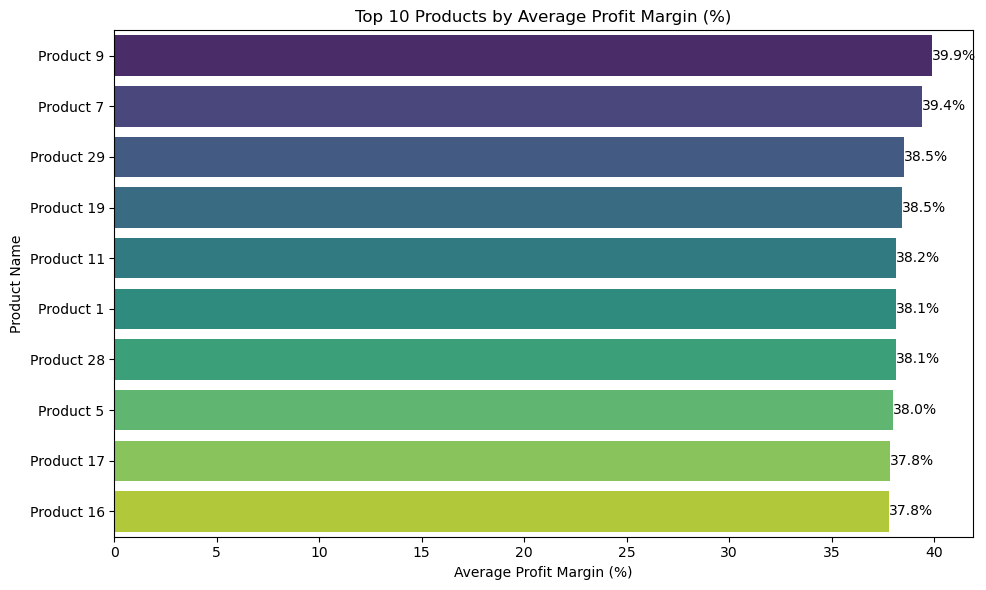

In [43]:
# Get top 10 products by avg profit margin
top_products = (
    df.groupby('product_name')['profit_margin_pct']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='viridis'
)

plt.title('Top 10 Products by Average Profit Margin (%)')
plt.xlabel('Average Profit Margin (%)')
plt.ylabel('Product Name')

# Add labels
for i, v in enumerate(top_products.values):
    plt.text(v, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

C:\Users\Maneesh\AppData\Local\Temp\ipykernel_19948\2172596597.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


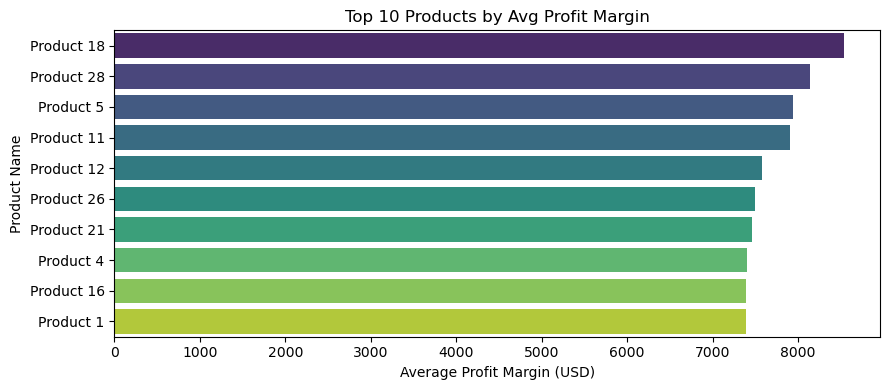

In [44]:
# Compute average profit per product and take the top 10
top_margin = (
    df.groupby('product_name')['profit']
      .mean()                        # Calculate mean profit for each product
      .sort_values(ascending=False)  # Sort from highest to lowest average profit
      .head(10)                      # Keep only the top 10 products
)

# Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart
sns.barplot(
    x=top_margin.values,    # X-axis: average profit values
    y=top_margin.index,     # Y-axis: product names
    palette='viridis'       # Color palette for the bars
)

# Add title and axis labels
plt.title('Top 10 Products by Avg Profit Margin')  # Chart title
plt.xlabel('Average Profit Margin (USD)')          # X-axis label
plt.ylabel('Product Name')                         # Y-axis label

# Adjust layout to prevent clipping and show the plot
plt.tight_layout()
plt.show()

#### Insights-
Products 9 and 7 lead (~39%–40%), slightly ahead of others.\
Most products cluster tightly around ~38%, showing consistent margins.\
Applying top-performer strategies could help lift overall profitability.

### 5. Sales by Channel (Pie Chart)
Goal: Show distribution of total sales across channels to identify dominant sales routes\
Chart: Pie chart\
EDA Type: Univariate\
Structure: Pie segments with percentage labels, colors for clarity, start angle adjusted

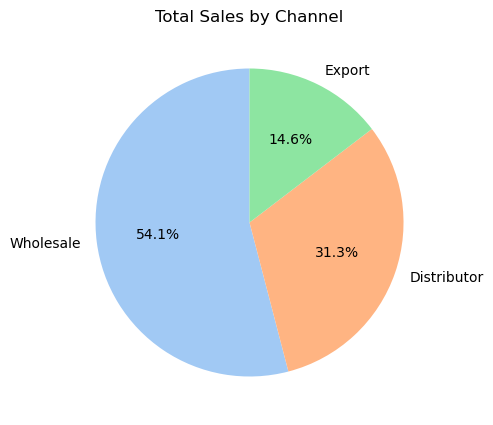

In [45]:
## Sales by Channel

# Group by channel and sum revenue
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

# Create color palette
colors = sns.color_palette('pastel')

# Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(chan_sales, labels=chan_sales.index, autopct='%1.1f%%',
        startangle=90, colors=colors)

plt.title('Total Sales by Channel')
plt.show()

#### Insights-
Wholesale accounts for 54 % of sales, with distributors at ~31 % and exports at ~15 %, underscoring reliance on domestic bulk channels.\
To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives—through targeted overseas marketing and strategic partner relationships.

### 6. Average Order Value (AOV) Distribution
Goal: Understand distribution of order values to identify typical spending levels and outliers\
Chart: Histogram\
EDA Type: Univariate\
Structure: Histogram with 50 bins, colored bars with edge highlights to show frequency of order values

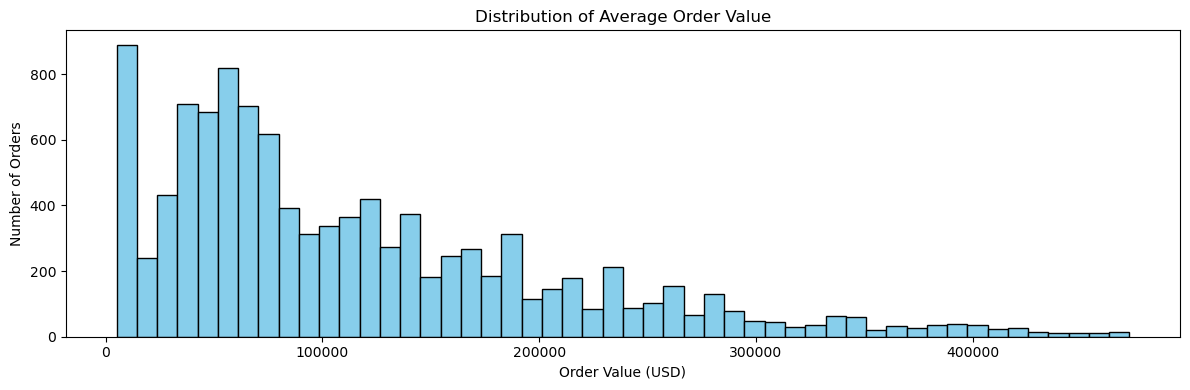

In [46]:
## Average Order Value(AOV) Distribution

# Calculate the total revenue for each order to get the order value
aov = df.groupby('order_number')['revenue'].sum()

# Set the figure size for better visibility
plt.figure(figsize=(12, 4))

# Plot a histogram of order values
plt.hist(
    aov,               # Data: list of order values
    bins=50,           # Number of bins to group order values
    color='skyblue',   # Fill color of the bars
    edgecolor='black'  # Outline color of the bars
)

# Add title and axis labels for context
plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

#### Insights-
The order‐value distribution is heavily right‐skewed, with most orders clustering between 20K and 120K and a pronounced mode around 50K-60K\
A long tail of high-value transactions extends up toward 400K-500K, but these large orders represent only a small share of total volume.

### 7. Profit Margin % vs. Unit Price
Goal: Examine relationship between unit price and profit margin percentage across orders\
Chart: Scatter plot\
EDA Type: Bivariate\
Structure: Scatter points with transparency to show data density

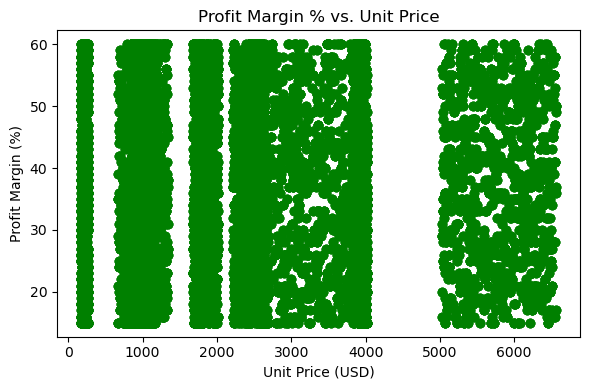

In [47]:
# Set the figure size for clarity
plt.figure(figsize=(6,4))

# Plot unit price vs. profit margin percentage
plt.scatter(
    df['unit_price'],            # X-axis: unit price in USD
    df['profit_margin_pct'],     # Y-axis: profit margin percentage
    alpha=0.6,                   # Transparency level for overlapping points
    color='green'                # Point color
)

# Add title and axis labels
plt.title('Profit Margin % vs. Unit Price')  # Chart title
plt.xlabel('Unit Price (USD)')                # X-axis label
plt.ylabel('Profit Margin (%)')               # Y-axis label

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()
     

#### Insights-
Profit margins are concentrated between ~18% and 60%, with no clear correlation to unit price, which spans from near 0 to 6,500.\
Dense horizontal bands indicate consistent margin tiers across a wide price spectrum, reflecting uniform pricing strategies.\
Outliers below 18% at both low and high price points may signal cost inefficiencies or pricing issues worth deeper investigation.

### 8. Unit Price Distribution per Product
Goal: Compare pricing variability across different products to identify price consistency and outliers\
Chart: Boxplot\
EDA Type: Bivariate\
Structure: Boxplot with rotated labels to display unit price spread per product

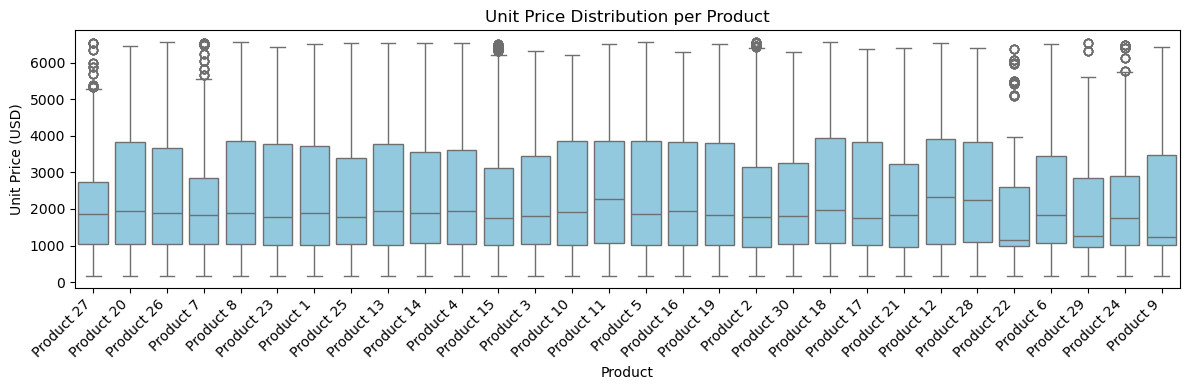

In [48]:
# Set figure size for clarity
plt.figure(figsize=(12,4))

# Create a boxplot of unit_price by product_name
sns.boxplot(
    data=df,
    x='product_name',   # X-axis: product categories
    y='unit_price',      # Y-axis: unit price values
    color='skyblue'            # Box color
)

# Add title and axis labels
plt.title('Unit Price Distribution per Product')  # Chart title
plt.xlabel('Product')                              # X-axis label
plt.ylabel('Unit Price (USD)')                     # Y-axis label

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

#### Insights-
High-end outliers (> 6K) indicate occasional premium or bulk sales.\
Wide price ranges (~1K–4K) suggest flexible pricing across products.\
Low-end outliers (< 500) reflect discounts or promotions.\
Most products show similar median prices, indicating standardized base pricing.\
Outliers should be excluded for more accurate pricing and margin analysis.

### 9. Total Sales by US Region
Goal: Compare total sales across U.S. regions to identify top‑performing markets and areas for targeted growth.\
Chart: Horizontal bar chart\
EDA Type: Univariate comparison\
Structure:
Bars sorted ascending (Northeast → West) for clear bottom‑to‑top ranking
X‑axis in millions USD, Y‑axis listing regions

C:\Users\Maneesh\AppData\Local\Temp\ipykernel_19948\1856339677.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


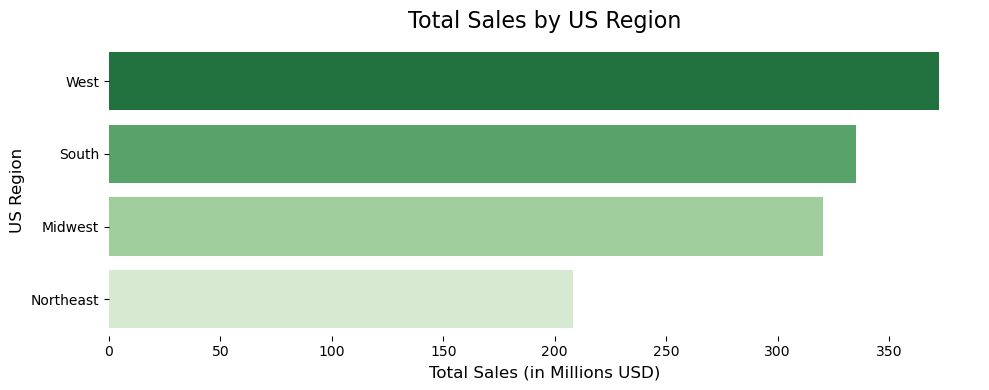

In [49]:
# 1. Aggregate total sales by region (in millions)
region_sales = (
    df
    .groupby('region')['revenue']
    .sum()
    .sort_values(ascending=False)  # so bars go top→bottom
    / 1e6                         # convert to millions
)

# 2. Plot
plt.figure(figsize=(10, 4))
sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    palette='Greens_r'          # dark→light green
)

# 3. Formatting
plt.title('Total Sales by US Region', fontsize=16, pad=12)
plt.xlabel('Total Sales (in Millions USD)', fontsize=12)
plt.ylabel('US Region', fontsize=12)
plt.xticks(rotation=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

#### Insights-
West dominates with roughly 360 M in sales (~35 % of total), underscoring its market leadership.\
South & Midwest each contribute over 320 M (~32 %), indicating strong, consistent demand across central regions.\
Northeast trails at about 210 M (~20 %), signaling room for growth and targeted investment.\
Action: Focus on closing the Northeast gap with local promotions and strategic partnerships, while maintaining national playbook success.

### 10. Total Sales by State (Choropleth Map)
Goal: Visualize geographic distribution of sales to identify high- and low-performing states and uncover regional gaps.\
Chart: US choropleth map\
EDA Type: Univariate geospatial\
Structure:
States shaded by total sales (in millions USD) using a blue gradient
Legend on the right showing sales scale (M USD)
Hover tooltips display exact sales for each state
Map scoped to USA for clear regional context\

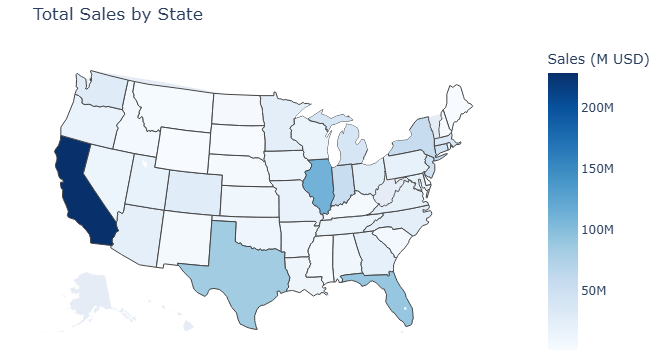

In [50]:
import plotly.express as px

# 1. Aggregate revenue by state (in millions)
state_sales = (
    df
    .groupby('state')['revenue']
    .sum()
    .reset_index()
)
state_sales['revenue_m'] = state_sales['revenue'] / 1e6  # convert to millions

# 2. Plotly choropleth
fig = px.choropleth(
    state_sales,
    locations='state',            # column with state codes
    locationmode='USA-states',    # tells Plotly these are US states
    color='revenue_m',
    scope='usa',
    labels={'revenue_m':'Total Sales (M USD)'},
    color_continuous_scale='Blues',
    hover_data={'revenue_m':':.2f'}  # show 2 decimals
)

# 3. Layout tuning
fig.update_layout(
    title_text='Total Sales by State',
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title='Sales (M USD)',
        ticksuffix='M'
    )
)

fig.show()

#### Insights-
California leads with 230M, followed by Illinois(112M) and Florida(90M), forming a dominant top-tier(>90M).\
Mid‑tier states (e.g., Texas 85M, NewYork 55 M) hold steady performance but trail the top three by 40–145 M.\
Lower‑tier states (e.g., New Jersey 47M, Massachusetts 35 M) reveal a gradual drop, indicating uneven market penetration.\
Action: Double down on top states with tailored promotions, and launch targeted growth initiatives in under‑penetrated regions to close the gap.

### 11. Top 10 States by Revenue and Order Count
Goal: Identify your highest- and lowest-revenue customers to tailor engagement strategies\
Chart: Side-by-side horizontal bar charts\
EDA Type: Multivariate\
Structure: Left chart shows top 10 customers by revenue (in millions), right chart shows bottom 10 customers by revenue (in millions)

C:\Users\Maneesh\AppData\Local\Temp\ipykernel_19948\1813795792.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Maneesh\AppData\Local\Temp\ipykernel_19948\1813795792.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




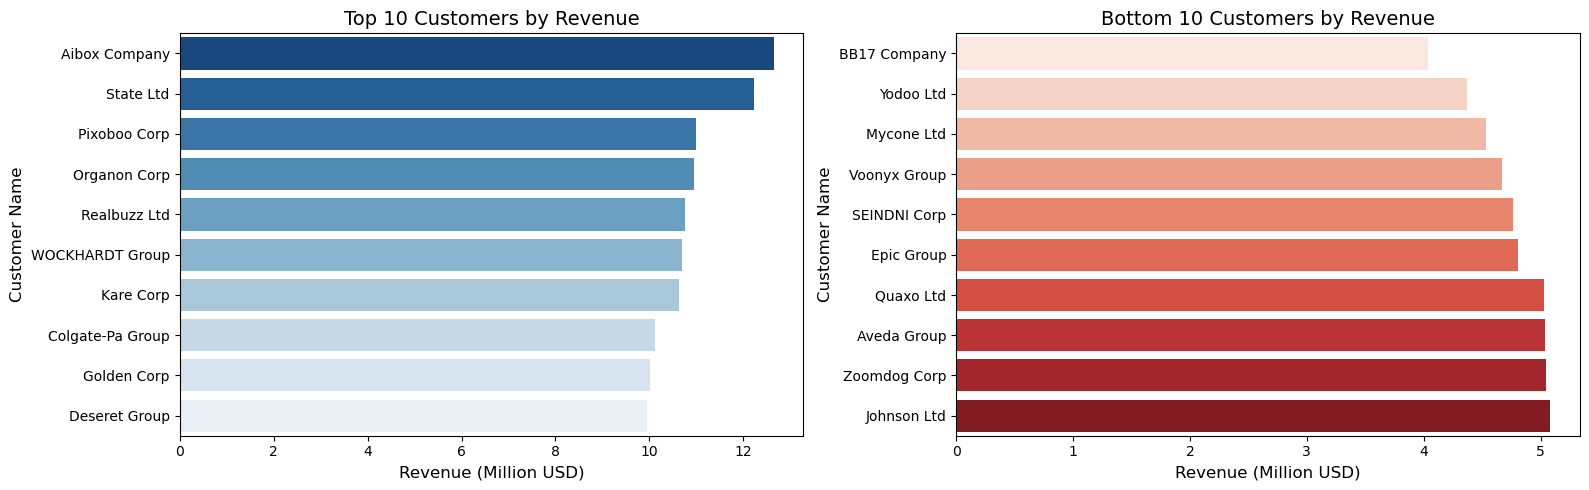

In [51]:
# Calculate total revenue per customer and select top 10
top_rev = (
    df.groupby('customer_name')['revenue']
      .sum()                        # Sum revenue for each customer
      .sort_values(ascending=False) # Sort from highest to lowest
      .head(10)                     # Keep top 10 customers
)

# Calculate total revenue per customer and select bottom 10
bottom_rev = (
    df.groupby('customer_name')['revenue']
      .sum()                        # Sum revenue for each customer
      .sort_values(ascending=True)  # Sort from lowest to highest
      .head(10)                     # Keep bottom 10 customers
)

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Top 10 customers by revenue (converted to millions)
sns.barplot(
    x=top_rev.values / 1e6,    # X-axis: revenue in millions
    y=top_rev.index,           # Y-axis: customer names
    palette='Blues_r',         # Color palette (reversed blues)
    ax=axes[0]                 # Draw on the left subplot
)
axes[0].set_title('Top 10 Customers by Revenue', fontsize=14)         # Title
axes[0].set_xlabel('Revenue (Million USD)', fontsize=12)              # X-axis label
axes[0].set_ylabel('Customer Name', fontsize=12)                      # Y-axis label

# Plot 2: Bottom 10 customers by revenue (converted to millions)
sns.barplot(
    x=bottom_rev.values / 1e6, # X-axis: revenue in millions
    y=bottom_rev.index,        # Y-axis: customer names
    palette='Reds',            # Color palette (reds)
    ax=axes[1]                 # Draw on the right subplot
)
axes[1].set_title('Bottom 10 Customers by Revenue', fontsize=14)      # Title
axes[1].set_xlabel('Revenue (Million USD)', fontsize=12)              # X-axis label
axes[1].set_ylabel('Customer Name', fontsize=12)                      # Y-axis label

# Adjust layout to prevent overlap and display both charts
plt.tight_layout()
plt.show()

#### Insights-
Aibox Company tops the list with 12.5M, followed closely by State Ltd (12.2 M), while the 10th-ranked Deseret Group still contributes 9.9M - demonstrating 10–12 M top tier.\
At the bottom, Johnson Ltd leads its group with 5.1M, down to BB17 Company 4.1 M—roughly half the top customer’s revenue.\
This steep drop from ~10M+ to 4–5 M highlights high revenue concentration among the top customers.\
Action: prioritize retention and upsell for your top ten, and launch targeted growth campaigns to elevate the lower-revenue cohort.

### 12. Average Profit Margin by Channel
Goal: Compare average profit margins across sales channels to identify the most and least profitable routes\
Chart: Bar chart\
EDA Type: Bivariate\
Structure: Vertical bars with data labels showing margin percentages, sorted descending by channel

C:\Users\Maneesh\AppData\Local\Temp\ipykernel_19948\4041412174.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




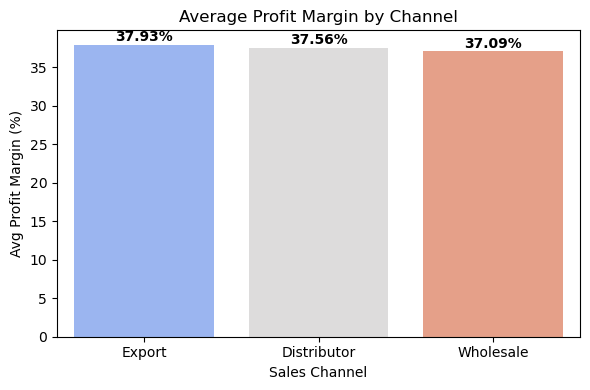

In [52]:
## Average Profit Margin by Channel
# Compute average profit margin percentage for each channel
channel_margin = (
    df.groupby('channel')['profit_margin_pct']  # Group by sales channel
      .mean()                                  # Calculate mean profit margin %
      .sort_values(ascending=False)            # Sort channels from highest to lowest margin
)

# Set the figure size for clarity
plt.figure(figsize=(6, 4))

# Plot a bar chart of average profit margin by channel
ax = sns.barplot(
    x=channel_margin.index,    # X-axis: channel names
    y=channel_margin.values,   # Y-axis: average profit margin values
    palette='coolwarm'         # Color palette for bars
)

# Add chart title and axis labels
plt.title('Average Profit Margin by Channel')  # Main title
plt.xlabel('Sales Channel')                    # X-axis label
plt.ylabel('Avg Profit Margin (%)')             # Y-axis label

# Annotate each bar with its exact margin percentage
for i, v in enumerate(channel_margin.values):
    ax.text(
        i,                  # X position (bar index)
        v + 0.5,            # Y position (bar height + small offset)
        f"{v:.2f}%",        # Text label showing percentage with two decimals
        ha='center',        # Center-align the text horizontally
        fontweight='bold'   # Bold font for readability
    )

# Adjust layout to prevent clipping and display the plot
plt.tight_layout()
plt.show()

#### Insights-
Export leads with a 37.93 % average margin, closely followed by Distributor (37.56 %) and Wholesale (37.09 %).\
The tiny spread (<0.2 %) shows consistently strong profitability across all channels.\
This uniformity implies well-controlled costs and pricing power everywhere.\
To maximize returns, push volume growth in Export while maintaining efficiency in Distributor and Wholesale.

### 13. Top 10 States by Revenue and Order Count
Goal: Identify highest revenue-generating states and compare their order volumes\
Chart: Two bar charts\
EDA Type: Multivariate\
Structure: First chart shows top 10 states by revenue (in millions), second shows top 10 states by number of orders

C:\Users\Maneesh\AppData\Local\Temp\ipykernel_19948\2018115719.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




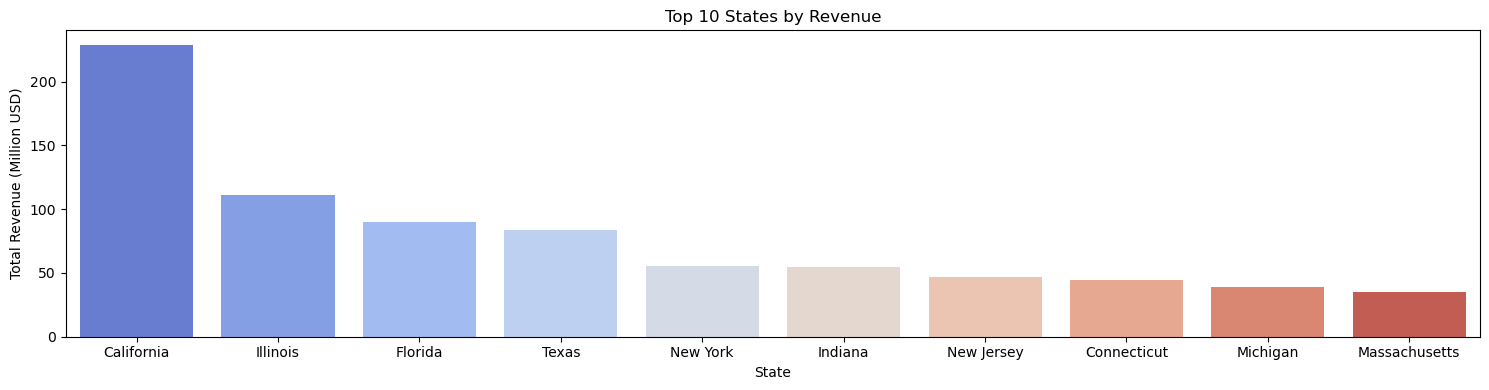

C:\Users\Maneesh\AppData\Local\Temp\ipykernel_19948\2018115719.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




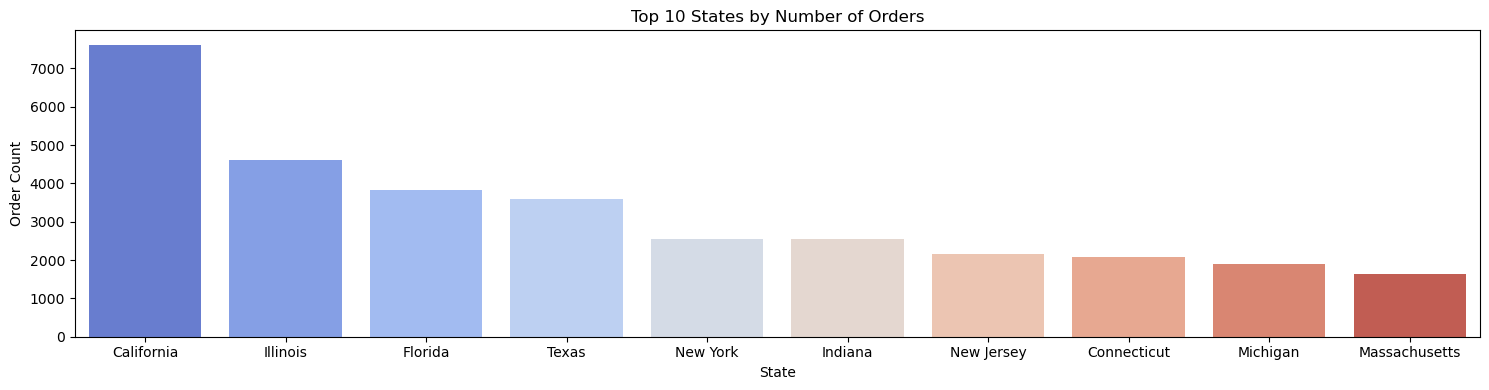

In [53]:
# Aggregate total revenue and unique order count per state
state_rev = df.groupby('state_name').agg(
    revenue=('revenue', 'sum'),          # Sum up revenue per state
    orders=('order_number', 'nunique')   # Count unique orders per state
).sort_values('revenue', ascending=False).head(10)  # Keep top 10 by revenue

# Plot 1: Top 10 states by revenue (scaled to millions)
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,                   # X-axis: state names
    y=state_rev['revenue'] / 1e6,        # Y-axis: revenue in millions
    palette='coolwarm'                   # Color palette
)
plt.title('Top 10 States by Revenue')     # Chart title
plt.xlabel('State')                       # X-axis label
plt.ylabel('Total Revenue (Million USD)') # Y-axis label
plt.tight_layout()                        # Adjust layout
plt.show()                                # Display the plot

# Plot 2: Top 10 states by number of orders
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,                   # X-axis: state names
    y=state_rev['orders'],               # Y-axis: order counts
    palette='coolwarm'                   # Color palette
)
plt.title('Top 10 States by Number of Orders')  # Chart title
plt.xlabel('State')                              # X-axis label
plt.ylabel('Order Count')                        # Y-axis label
plt.tight_layout()                               # Adjust layout
plt.show()                                       # Display the plot

#### Insights-
California dominates both revenue and orders, indicating it is the strongest and most valuable market by a large margin.\
Illinois, Florida, and Texas form the next tier, showing solid performance but significantly behind California, suggesting growth potential.\
Lower-ranked states contribute relatively small volumes, indicating either weaker demand or opportunities for targeted expansion strategies.

### 14. Customer Segmentation: Revenue vs. Profit Margin
Goal: Segment customers by total revenue and average profit margin, highlighting order volume\
Chart: Bubble chart (scatter plot with variable point sizes)\
EDA Type: Multivariate\
Structure: Scatter points sized by number of orders, plotting revenue vs. margin

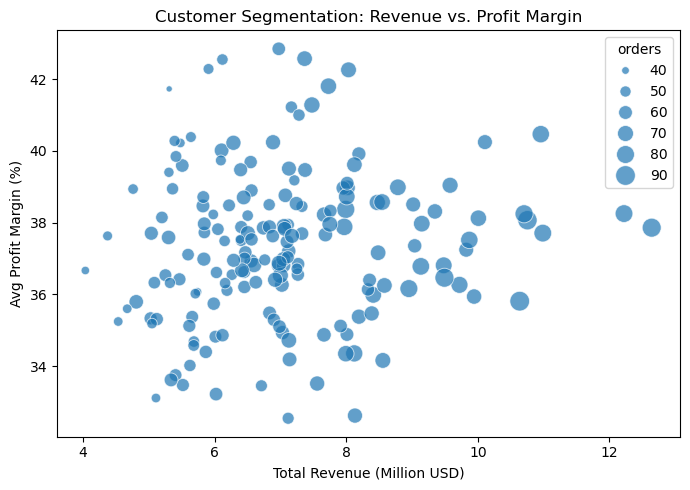

In [54]:
## Customer Segmentation: Revenue vs Profit Margin
# Aggregate metrics per customer
cust_summary = df.groupby('customer_name').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin_pct', 'mean'),
    orders=('order_number', 'nunique')
)

# Convert revenue to millions
cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

plt.figure(figsize=(7, 5))

# Bubble chart with revenue in millions
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',        # <-- use revenue in millions
    y='avg_margin',
    size='orders',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin')
plt.xlabel('Total Revenue (Million USD)')  # <-- updated label
plt.ylabel('Avg Profit Margin (%)')

plt.tight_layout()
plt.show()

#### Insights-
Most customers cluster around 6–8M revenue with 36–40% margins, indicating a stable core segment driving consistent performance.\
High-revenue customers (10M+) don’t always have higher margins, suggesting growth may be coming at the cost of profitability.\
A few low-revenue but high-margin segments exist, representing potential niche opportunities to scale profitably.

### 15. Correlation Heatmap of Numeric Features
Goal: Identify relationships among key numeric variables to uncover potential multicollinearity\
Chart: Correlation heatmap\
EDA Type: Multivariate\
Structure: Annotated heatmap with correlation coefficients for selected numeric columns

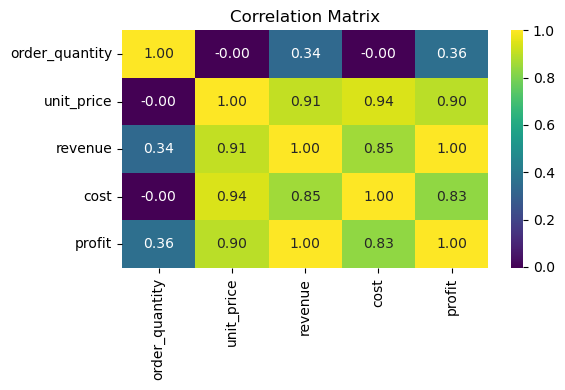

In [55]:
## Correlation Heatmap of Numeric Features
# Create profit column (if not already present)
df['profit'] = df['revenue'] - df['cost']

# List correct numeric columns
num_cols = ['order_quantity', 'unit_price', 'revenue', 'cost', 'profit']

# Correlation matrix
corr = df[num_cols].corr()

# Plot
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='viridis'
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Insights-
Profit and revenue are very strongly correlated (0.87), indicating that as sales value increases, profit tends to rise as well.\
Unit price is a key driver: it correlates 0.91 with revenue, 0.79 with profit, and 0.94 with cost—highlighting how pricing decisions ripple through both top‑line and expense figures.\
Cost shows a strong link to revenue (0.85) but a more moderate tie to profit (0.58), underscoring that while higher sales often bring higher expenses, margins can still vary.\
Quantity has virtually no correlation with unit price or cost (≈0.00) and only modest associations with revenue (0.34) and profit (0.30), making volume a secondary factor compared to pricing.

### Saving Pre-Processed Dataframe

In [56]:
# Export Final DataFrame to CSV
df.to_csv('Sales_data(EDA Exported).csv', index=False)

### Key Insights

#### Monthly Revenue Cycle:
Revenue stays stable between ≈23M to 26.5M across 2014–2017, with no consistent seasonal spikes. Sharpest drop (≈21.2M) occurs in early 2017, indicating a possible one-time disruption.\

#### Channel Mix:
Wholesale: 54%. Distributors: 31%. Exports: 15% — opportunity to scale international presence.\

#### Top Products (Revenue):
Product 26: 118M; Product 25: 110M; Product 13: 78M. Mid-tier:68–75M; bottom performers: 52–57M.\

#### Profit Margins:
Profit margins range broadly from ≈18% to ≈60%, with no strong correlation to unit price. Dense horizontal bands suggest standardized pricing strategies across tiers.\

#### Seasonal Volume:
No strong monthly pattern, but slight volume uptick appears around May–June. Early 2017 dip (≈$21.2M) may require investigation.\

#### Regional Performance:
California leads: ≈230M Revenue & 7500+ orders. Illinois/Florida/Texas: ≈ 85M–110M & ≈3500–4500 orders. NY/Indiana: ≈ 54M & 2000+ orders.